# Push-T Inspection

# Imports and Paths

In [4]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import hdf5plugin

REPO_ROOT = Path.cwd().parents[1] #Have to go up one
H5_PATH = REPO_ROOT / "Safety-Dial" / "data" / "processed" / "pusht_expert_train.h5" #Training data provided by SWM

In [5]:
H5_PATH

PosixPath('/workspace/Safety-Dial/data/processed/pusht_expert_train.h5')

In [6]:
if not H5_PATH.exists():
    raise FileNotFoundError(f"Nothing there, run download_data.py")

# Exploring the h5

In [7]:
file = h5py.File(H5_PATH, "r")

In [8]:
print(list(file.keys()))

['action', 'ep_len', 'ep_offset', 'episode_idx', 'pixels', 'proprio', 'state', 'step_idx']


In [9]:
for key in file.keys():
    item = file[key]
    print(f"{key:12s}  shape={str(item.shape):25s}  dtype={item.dtype}")

action        shape=(2336736, 2)               dtype=float32
ep_len        shape=(18685,)                   dtype=int32
ep_offset     shape=(18685,)                   dtype=int64
episode_idx   shape=(2336736,)                 dtype=int64
pixels        shape=(2336736, 224, 224, 3)     dtype=uint8
proprio       shape=(2336736, 4)               dtype=float32
state         shape=(2336736, 7)               dtype=float32
step_idx      shape=(2336736,)                 dtype=int64


State $\rightarrow$ Full physical state agent pos (2), block pos (2), block angle (1), agent vel (2)  
Refs at: https://galilai-group.github.io/stable-worldmodel/envs/pusht/

## Looking at the state

In [10]:
state_names = [
    "agent_x", "agent_y",
    "block_x", "block_y", "block_angle",
    "agent_vx", "agent_vy",
] #From our ref

In [11]:
state = file["state"]

In [12]:
print("first 3 rows:\n", state[:3])

first 3 rows:
 [[423.        182.        192.67061   335.15677     2.9476998   0.
    0.       ]
 [427.1394    174.6082    192.67061   335.15677     2.9476998  52.380672
  -93.53691  ]
 [430.44006   169.26328   192.67061   335.15677     2.9476998  21.584066
  -31.594496 ]]


In [13]:
s = state[:] #Reading into mem
print(f"{'name':10s}  {'min':>10s}  {'max':>10s}")
for i, name in enumerate(state_names):
    print(f"{name:10s}  {s[:, i].min():10.4f}  {s[:, i].max():10.4f}")

name               min         max
agent_x      -153.0066    666.1378
agent_y       -90.5952    723.6395
block_x       -32.8419    507.5937
block_y        -1.8579    538.7749
block_angle      0.0000      6.2832
agent_vx     -558.1359    762.6093
agent_vy     -546.0454    669.1609


## Looking at the episodes

In [14]:
ep_offset = file["ep_offset"][:]
ep_len = file["ep_len"][:]

print("n_episodes", len(ep_len))
print("ep_len min/mean/max", ep_len.min(), ep_len.mean(), ep_len.max())


n_episodes 18685
ep_len min/mean/max 49 125.05945945945946 246


### Looking at a single EP

In [15]:
i = 0
start, end = int(ep_offset[i]), int(ep_offset[i] + ep_len[i])
ep = s[start:end]
print(f"episode {i}: T={end-start}, start state={ep[0]}, end state={ep[-1]}")

episode 0: T=109, start state=[423.        182.        192.67061   335.15677     2.9476998   0.
   0.       ], end state=[157.33342   356.94244   251.5964    260.31262     0.7770067  23.641151
 -25.708391 ]


### Plotting the path of the EP

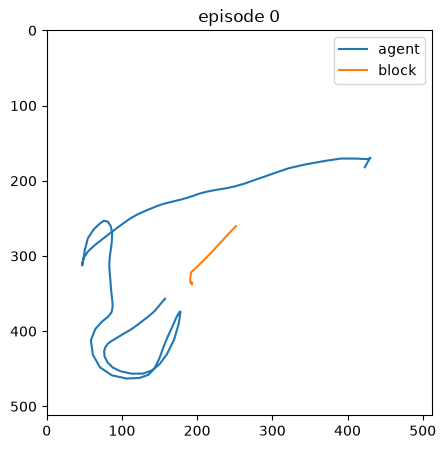

In [16]:
ep = s[start:end]
plt.figure(figsize=(5, 5))
plt.plot(ep[:, 0], ep[:, 1], label="agent")
plt.plot(ep[:, 2], ep[:, 3], label="block")
plt.xlim(0, 512); plt.ylim(0, 512)
plt.gca().invert_yaxis()  # Push-T image coords
plt.legend(); plt.gca().set_aspect("equal")
plt.title(f"episode {i}")
plt.show()

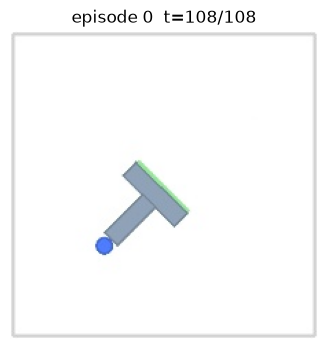

In [17]:
frames = file["pixels"][start:end]  # (T, 224, 224, 3) — one episode only

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(frames[0])
ax.set_title(f"episode {i}")
ax.axis("off")

def update(t):
    im.set_data(frames[t])
    ax.set_title(f"episode {i}  t={t}/{len(frames)-1}")
    return (im,)

ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=50, blit=True)
HTML(ani.to_jshtml())

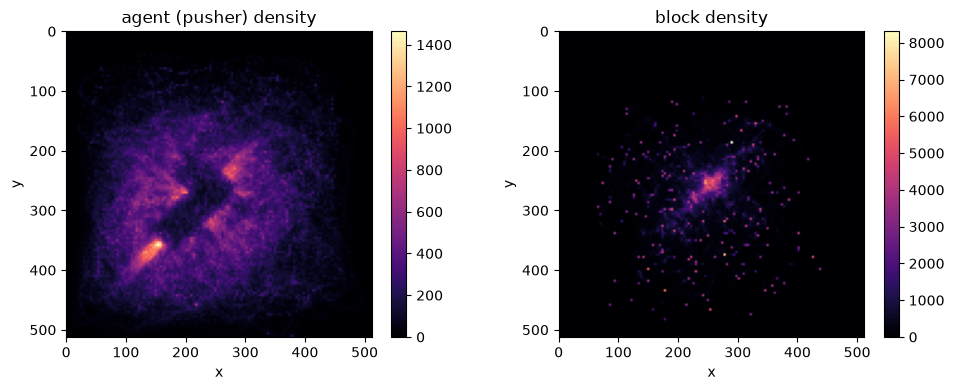

In [18]:
agent_xy = s[:, 0:2]
block_xy = s[:, 2:4]

ARENA = 512
BINS = 128
range_xy = [[0, ARENA], [0, ARENA]]

agent_H, xedges, yedges = np.histogram2d(
    agent_xy[:, 0], agent_xy[:, 1], bins=BINS, range=range_xy
)
block_H, _, _ = np.histogram2d(
    block_xy[:, 0], block_xy[:, 1], bins=BINS, range=range_xy
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, H, title in [
    (axes[0], agent_H, "agent (pusher) density"),
    (axes[1], block_H, "block density"),
]:
    im = ax.imshow(
        H.T,
        origin="upper",        
        extent=[0, ARENA, ARENA, 0],
        aspect="equal",
        cmap="magma",
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

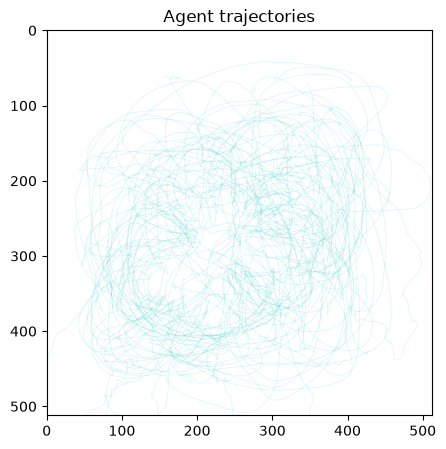

In [19]:
fig, ax = plt.subplots(figsize=(5, 5))
for i in range(0, len(ep_offset), max(1, len(ep_offset)//50)):  # ~50 episodes
    a, b = int(ep_offset[i]), int(ep_offset[i] + ep_len[i])
    traj = s[a:b, 0:2]
    ax.plot(traj[:, 0], traj[:, 1], "c-", alpha=0.15, lw=0.5)
ax.set_xlim(0, 512); ax.set_ylim(512, 0)  # y inverted
ax.set_aspect("equal")
ax.set_title("Agent trajectories")
plt.show()